This notebook produces Figures 4-6, which loads in the average coherence with gamma1 and gamma2 and plots them.
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel.
***

In [8]:
#import necessary packages
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
%matplotlib  widget

In [9]:
# load average coherence (average gamma1 and average gamma2)
# saveDir_avg = '/data/ocp4/SuperstitionHills/Data_and_Figs/coherence/comparing_coh_methods/AverageCohImages/'
saveDir_avg = '../../2_Calculating_coherence_2_ways/'

fileNameAvg_1 = 'avg_coh_method1.r4'  
f1 = gdal.Open(saveDir_avg + fileNameAvg_1, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m1 = f1.ReadAsArray()
f1 = None

fileNameAvg_2 = 'avg_coh_method2.r4'  
f2 = gdal.Open(saveDir_avg + fileNameAvg_2, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m2 = f2.ReadAsArray()
f2 = None

#calculate differences between method 1 and method 2
capped_m2 = np.where(coh_avg_m2 > 0.8475, 0.8475, coh_avg_m2)
diff_avg = coh_avg_m1 - capped_m2
diff = coh_avg_m1 - coh_avg_m2

In [10]:
# define dimensions of the full resolution image/area
dx= 9000; dy=1575

# this is the aspect ratio for plotting that maintains the geographic aspect ratio for visual similarity 
# I used Google Earth to measure the height and width of the ROI in km, this can be updated for other ROIs in a similar way.
aspect_rat = (21.8/dy) / (34.44/dx) 

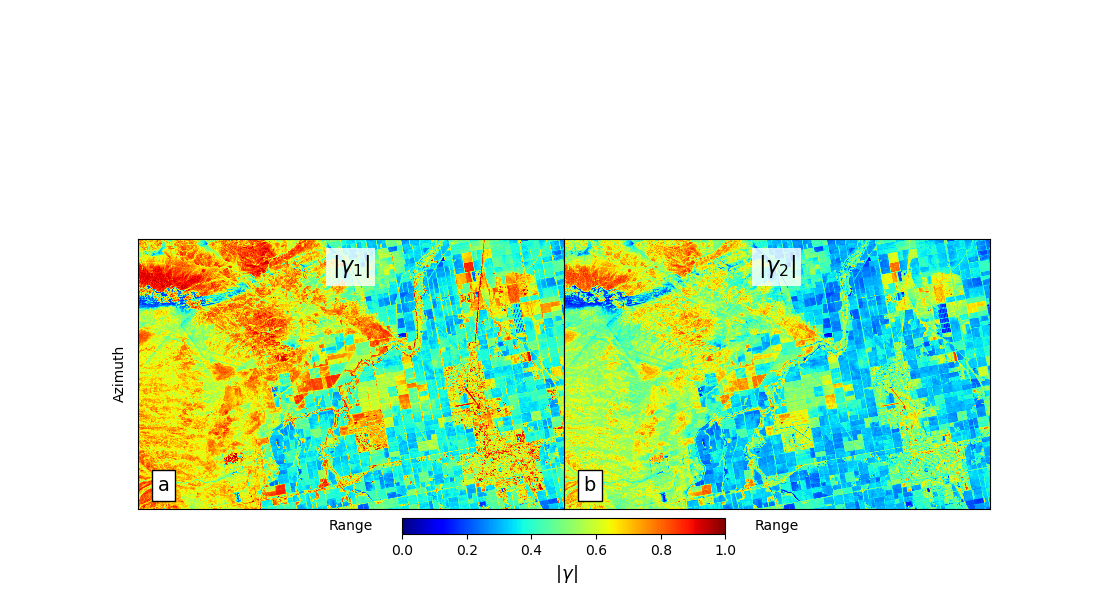

In [11]:
# plot it with more details for actual paper/thesis
fig, axs = plt.subplots(1,2,figsize=(11,6)) 
plt.subplots_adjust(wspace=0.0)
label_x = 0.075
label_y = 0.05
props = dict(boxstyle='square',facecolor='white',edgecolor='black')

ax = axs[0]
im = ax.imshow(coh_avg_m1,aspect=aspect_rat,interpolation='none',cmap='jet',vmin=0,vmax=1)
ax.set_xlim(dx,0)
ax.set_xlabel('Range'); ax.set_ylabel('Azimuth')
ax.set_xticks([]); ax.set_yticks([])
ax.text(dx-dx/2,200,'|$\gamma_{1}|$',fontsize=16,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

cbar = plt.colorbar(im,ax=axs,pad=0.02,orientation='horizontal',fraction=0.035)
cbar.set_label(label=' $|\gamma|$',size = 13)

ax = axs[1]
ax.imshow(coh_avg_m2,aspect=aspect_rat,interpolation='none',cmap='jet',vmin=0,vmax=1)
ax.set_xlim(dx,0)
ax.set_xlabel('Range')
ax.set_xticks([]); ax.set_yticks([])
ax.text(dx-dx/2,200,'|$\gamma_{2}|$',fontsize=16,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

#plt.savefig('/home/ocp4/data/SuperstitionHills/Data_and_Figs/figs_for_paper/avg_cohs.png',transparent=True,bbox_inches='tight',dpi=500)
plt.show()

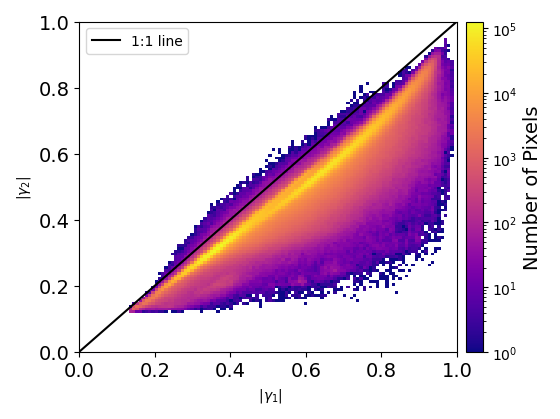

In [12]:
# plot 2D histogram of gamma1 vs gamma2
alooks = 4
rlooks = 20
plt.figure(figsize=(4*1.4,3*1.4),tight_layout=True)
plt.hist2d(coh_avg_m1[int(alooks/2):dy-int(alooks/2),int(rlooks/2):dx-int(rlooks/2)].flatten(),coh_avg_m2[int(alooks/2):dy-int(alooks/2),int(rlooks/2):dx-int(rlooks/2)].flatten(),bins=100,cmap='plasma',norm=mcolors.LogNorm())
Xmin,Xmax = 0,1
plt.plot([Xmin,Xmax],[Xmin,Xmax],'k-',label='1:1 line')
cbar = plt.colorbar(pad=0.02)
cbar.set_label(label='Number of Pixels',size = 14)
plt.xlabel(' $|\gamma_{1}|$')
plt.ylabel('$|\gamma_{2}|$')    
plt.xlim(0,1); plt.ylim(0,1) 
plt.xticks(fontsize = 14); plt.yticks(fontsize = 14)
plt.legend()
plt.show()
#plt.savefig('coh_heatmap.png',transparent=True,bbox_inches='tight',dpi=500)

In [13]:
# Define the focus areas to outline 
# We selected these manually based on surface types/structures of particular interest
imperial_road = [6820, 100, 7520, 450]
transect_roads = [4500, 650, 6600, 1000]     
ElCentro_airport = [4575, 985, 5275,1260]
pools = [7700,300, 8400, 650]
imperial_airport = [6600,800,7300,1075]

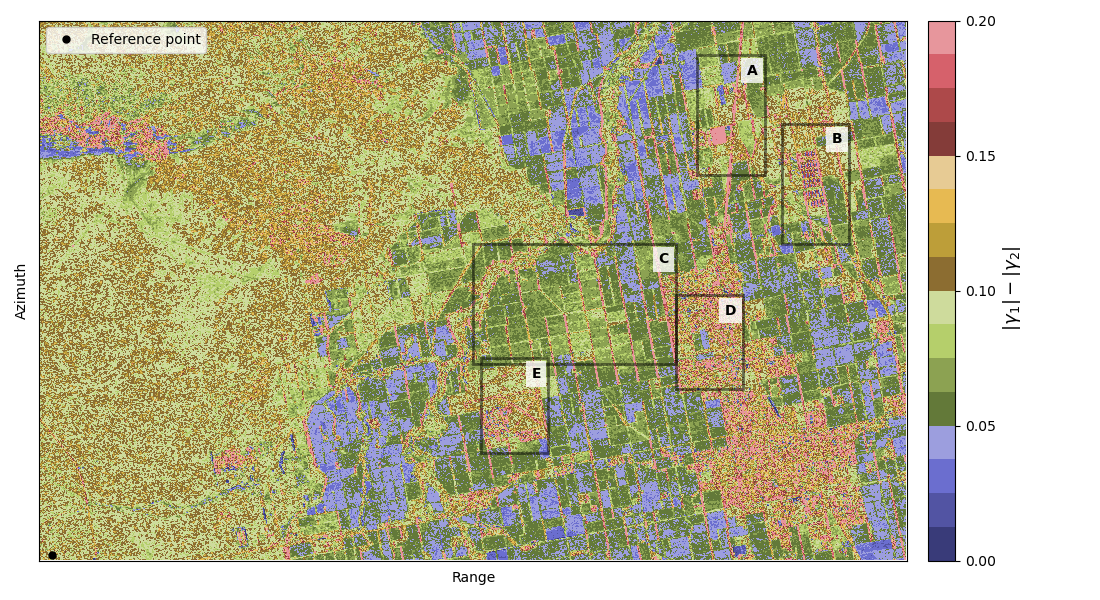

In [14]:
# plot the average coherence differences between gamma1 and gamma2
plt.figure(figsize=(11,6),tight_layout=True)
orig_cmap = plt.get_cmap('tab20b') 
colors = orig_cmap(np.linspace(0, 1, 20))
subset_colors = colors[:16]
new_cmap = ListedColormap(subset_colors)
plt.imshow(np.fliplr(diff),aspect='auto',interpolation = 'none',cmap=new_cmap, vmin = 0, vmax = 0.20)
cbar = plt.colorbar(pad=0.02,ticks = [0,0.05,0.1,0.15,0.2])#
cbar.set_label(label=' $|\gamma_{1}| - |\gamma_{2}| $',size = 13)
#adding patches for zoom_ins
imp_roads_rect = patches.Rectangle((imperial_road[0], imperial_road[3]), imperial_road[2]- imperial_road[0], imperial_road[1]- imperial_road[3], linewidth=2, edgecolor='k', facecolor = 'None', alpha=0.5) #imperial_road
plt.gca().add_patch(imp_roads_rect)
tsct_roads_rect = patches.Rectangle((transect_roads[0], transect_roads[3]), transect_roads[2]- transect_roads[0], transect_roads[1]- transect_roads[3], linewidth=2, edgecolor='k', facecolor = 'None', alpha=0.5) #imperial_road
plt.gca().add_patch(tsct_roads_rect)
el_airport_rect = patches.Rectangle((ElCentro_airport[0], ElCentro_airport[3]), ElCentro_airport[2]- ElCentro_airport[0], ElCentro_airport[1]- ElCentro_airport[3], linewidth=2, edgecolor='k', facecolor = 'None', alpha=0.5) #imperial_road
plt.gca().add_patch(el_airport_rect)
pools_rect = patches.Rectangle((pools[0], pools[3]), pools[2]- pools[0], pools[1]- pools[3], linewidth=2, edgecolor='k', facecolor = 'None', alpha=0.5) #imperial_road
plt.gca().add_patch(pools_rect)
imp_airport_rect = patches.Rectangle((imperial_airport[0], imperial_airport[3]), imperial_airport[2]- imperial_airport[0], imperial_airport[1]- imperial_airport[3], linewidth=2, edgecolor='k', facecolor = 'None', alpha=0.5) #imperial_road
plt.gca().add_patch(imp_airport_rect)
plt.xticks([]); plt.yticks([])
plt.xlabel('Range'); plt.ylabel('Azimuth')
# plot the reference point 
yR = int(1559)  
xR = int(130) 
plt.plot(xR,yR,'k.',ms=10,label='Reference point')
plt.legend(loc='upper left')
# add focus area labels 
plt.text(imperial_road[2]-75,imperial_road[1]+25,'A',fontsize=10,fontweight='bold',ha='right',va='top', \
         bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
plt.text(pools[2]-75,pools[1]+25,'B',fontsize=10,fontweight='bold',ha='right',va='top', \
         bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
plt.text(transect_roads[2]-75,transect_roads[1]+25,'C',fontsize=10,fontweight='bold',ha='right',va='top', \
         bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
plt.text(imperial_airport[2]-75,imperial_airport[1]+25,'D',fontsize=10,fontweight='bold',ha='right',va='top', \
         bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
plt.text(ElCentro_airport[2]-75,ElCentro_airport[1]+25,'E',fontsize=10,fontweight='bold',ha='right',va='top', \
         bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
#plt.savefig('coh_diffs.png',transparent=True,bbox_inches='tight',dpi=500)
plt.show()